In [55]:
import numpy as np

In [158]:
!pip install python-louvain

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9402 sha256=b18190687b799b10ff0ca761dbd72cc0ce0a8136a59d8aee0551351103aea7d0
  Stored in directory: c:\users\tanya\appdata\local\pip\cache\wheels\40\f1\e3\485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain


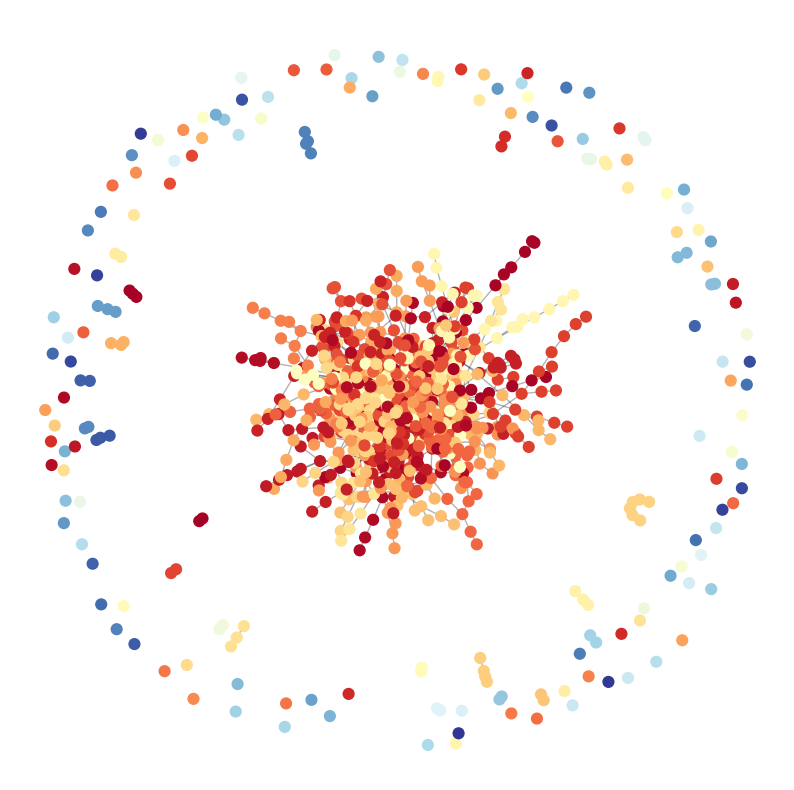

In [187]:
import networkx as nx
import community
import matplotlib.pyplot as plt
import random

H = nx.Graph()
nodes = list(range(1000))

H.add_nodes_from(nodes)  # Add all 1000 nodes explicitly

for i in range(1000):
    src = random.choice(nodes)
    dest = random.choice(nodes)
    while src == dest:
        dest = random.choice(nodes)
    H.add_edge(src, dest)

partition = community.best_partition(H)  # compute communities

pos = nx.spring_layout(H)  # compute graph layout
plt.figure(figsize=(10, 10))
plt.axis('off')
nx.draw_networkx_nodes(H, pos, node_size=60, cmap=plt.cm.RdYlBu, node_color=list(partition.values()))
nx.draw_networkx_edges(H, pos, alpha=0.3)
plt.show(H)

In [363]:
# import networkx as nx
m = 500
size = m
n_communities = int(np.sqrt(m) / 2)
print(f'n_communities: {n_communities}')

community_size = size // n_communities
sizes = [community_size] * n_communities
if size % n_communities:
    sizes[-1] += size % n_communities
# Probability parameters for sparse community structure
p_in = 0.7
p_out = (1 - p_in) / n_communities # Very sparse between-community connections
# Generate probability matrix
p_matrix = [
    [p_in if i == j else p_out for j in range(n_communities)]
    for i in range(n_communities)
]
# Create graph using stochastic block model
G = nx.stochastic_block_model(sizes, p=p_matrix)
# Get adjacency matrix and compute Laplacian

n_communities: 11


In [364]:
A = nx.adjacency_matrix(G).toarray()
D = np.diag(np.sum(A, axis=1))
laplacian1 = D - A

In [365]:
laplacian1

array([[53, -1, -1, ...,  0,  0,  0],
       [-1, 39, -1, ...,  0,  0,  0],
       [-1, -1, 43, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 47, -1, -1],
       [ 0,  0,  0, ..., -1, 46, -1],
       [ 0,  0,  0, ..., -1, -1, 54]])

In [366]:
Lambda_r, U_r = np.linalg.eigh(laplacian1)
# Lambda_c, U_c = np.linalg.eigh(laplacian2)

# Sort eigenvalues and eigenvectors in ascending order
# idx_r = np.argsort(Lambda_r)
# idx_c = np.argsort(Lambda_c)
# Lambda_r = Lambda_r[idx_r]
# Lambda_c = Lambda_c[idx_c]
# U_r = U_r[:, idx_r]
# U_c = U_c[:, idx_c]

# Function g acting element-wise on eigenvalues
# Apply g to all eigenvalues while avoiding small values
p=2
# g_transformed_r = np.where(
#     np.abs(Lambda_r) > 1e-10, Lambda_r, Lambda_r
# )
g_transformed_r = np.where(
    np.abs(Lambda_r) > 1e-10, np.power(Lambda_r, -p), Lambda_r
)

# g_transformed_r = Lambda_r
# g_transformed_c = Lambda_c

# Compute A matrices according to equation (52)
A_r = U_r @ np.diag(g_transformed_r)
# A_c = U_c @ np.diag(g_transformed_c)
# g_transformed_r.shape

In [367]:
A_r.shape

(500, 500)

Text(0.5, 1.0, '(b)')

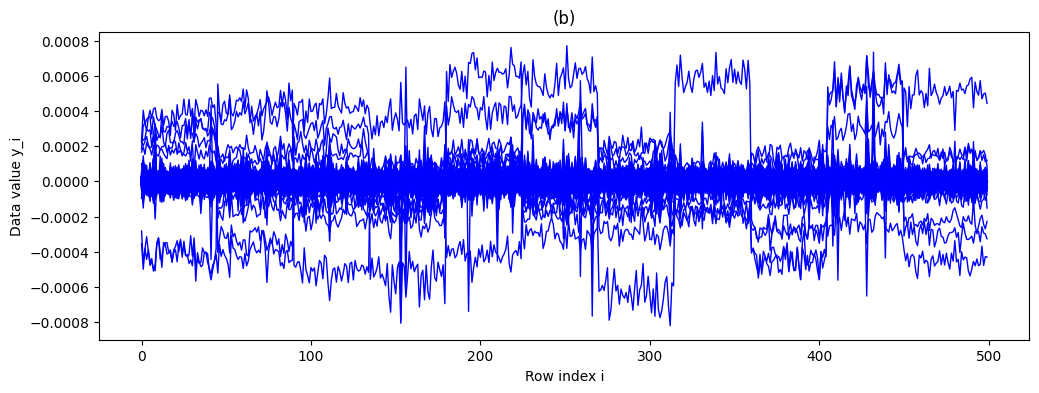

In [368]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(A_r, 'b-', linewidth=1)
ax.set_xlabel('Row index i')
ax.set_ylabel('Data value y_i')
ax.set_title('(b)')

(500, 600)


Text(0.5, 1.0, '(b)')

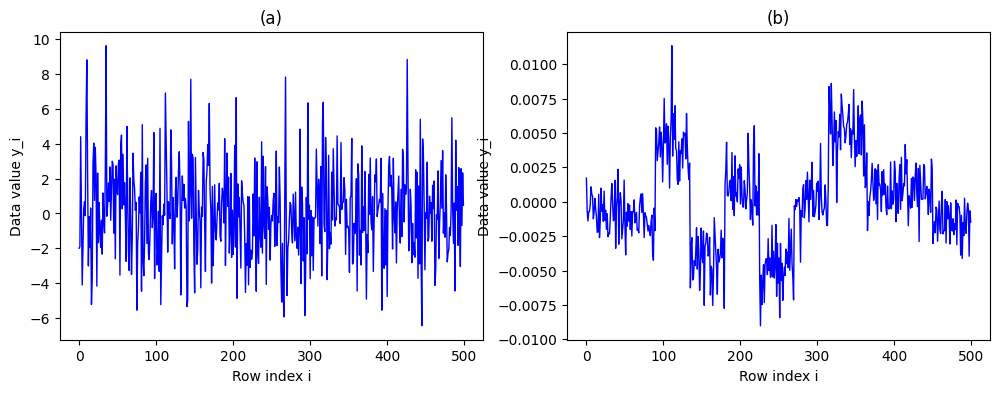

In [369]:
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

m = 500
n = 600
r_s = 12
F = np.random.randn(m, r_s)
Q = np.random.randn(n, r_s)
Z = F @ Q.T
print(Z.shape)
# Z = np.eye(5, 3)
X = A_r @ Z

i=100
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(Z[:, i], 'b-', linewidth=1)
ax1.set_xlabel('Row index i')
ax1.set_ylabel('Data value y_i')
ax1.set_title('(a)')

# Plot second matrix
ax2.plot(X[:, i], 'b-', linewidth=1)
ax2.set_xlabel('Row index i')
ax2.set_ylabel('Data value y_i')
ax2.set_title('(b)')
